# 00 · The Forward Method and Deconvolution

**A gentle, visual tour of the whole programme — from the ground up.**

This is the first of a series of notebooks that teach, step by step, everything we
discovered. No prior knowledge is assumed. We build the ideas with pictures.

The story in one line: we invented an *exact inverse* for a certain kind of system.
Given only the *behaviour* of a network, we recover the network itself — who is
wired to whom, and what rule each node follows — with no error. Later notebooks
apply this to cellular automata, to biology, and finally to financial markets,
where the exact method fails honestly and points us to a deeper, statistical kind
of order.

> **How to run.** Pick the kernel called **CausalBool** (top-right). Then run the
> cells in order. The first cell makes the notebook work from any folder.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. What is a Boolean network?

Imagine a row of light switches. Each switch is a **node**. At every tick of a
clock, each switch looks at a few of the *other* switches and decides whether to be
ON (1) or OFF (0), following a fixed rule called a **gate** (AND, OR, XOR, …).

A network is therefore three things:

* **who listens to whom** — the wiring (a matrix `C`, where `C[k][i] = 1` means node
  *i* feeds node *k*);
* **the rule at each node** — its gate;
* nothing else. The future is a deterministic function of the present.

Let us build a tiny 3-node network by hand.

In [2]:
from causalbool import Network, repertoire, node_output_column

In [3]:

# C[k][i] = 1  means node i is an input of node k
net = Network(
    n=3,
    C=[[0, 1, 1],    # node 0 listens to nodes 1 and 2
       [1, 0, 1],    # node 1 listens to nodes 0 and 2
       [1, 1, 0]],   # node 2 listens to nodes 0 and 1
    gates=["AND", "OR", "XOR"],
)
for k in range(net.n):
    print(f"node {k}: gate {net.gates[k]:4s}  inputs {net.connected_inputs(k)}")

node 0: gate AND   inputs [1, 2]
node 1: gate OR    inputs [0, 2]
node 2: gate XOR   inputs [0, 1]


## 2. The forward method: the *repertoire*

If we feed the network **every possible input state** (for 3 nodes there are
$2^3 = 8$ of them) and write down what each node outputs, we get a table called the
**repertoire**: 8 rows (one per input state), 3 columns (one per node). This table
is the network's complete *behaviour* — everything it can ever do.

In [4]:
# computes the output repertoire for this network
rep = repertoire(net)          # 2**n rows x n columns
rep = np.array(rep)
rep

array([[0, 0, 0],
       [0, 1, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 1],
       [1, 1, 1],
       [1, 1, 0]])

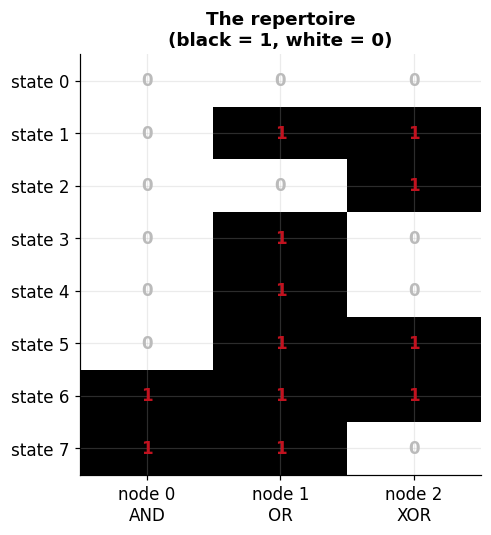

Each column is one node's complete behaviour. That is all the deconvolution sees.


In [5]:

fig, ax = plt.subplots(figsize=(4.6, 5))
ax.imshow(rep, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(net.n)); ax.set_xticklabels([f"node {k}\n{net.gates[k]}" for k in range(net.n)])
ax.set_yticks(range(2**net.n)); ax.set_yticklabels([f"state {r}" for r in range(2**net.n)])
ax.set_title("The repertoire\n(black = 1, white = 0)")
for (i, j), v in np.ndenumerate(rep):
    ax.text(j, i, v, ha="center", va="center", color=HL if v else "#bbb", fontweight="bold")
plt.tight_layout(); plt.show()
print("Each column is one node's complete behaviour. That is all the deconvolution sees.")

## 3. The inverse problem

Now play the game the other way round. **Hide the network. Show only the
OUTPUT repertoire.** Can we recover the wiring and the gates from the behaviour alone?

Yes — exactly. The trick is that the behaviour *factorises*: column *k* of the
repertoire depends only on the inputs of node *k*. So we solve one column at a
time.

### Step 1 — which inputs actually matter (perturbation)

To find the inputs of a node we use a simple, exact test. Take its output column.
**Flip one input bit** (with everything else fixed) and see whether the output ever
changes. If it does, that input is *essential* (a real wire). If flipping it never
changes anything, it is not connected. This is a causal test, not a statistical
one.

In [6]:
from causalbool import input_vector
from deconvolution import essential_variables

k = 0                                  # inspect node 0 (an AND of nodes 1 and 2)
# given a node k of the Network net, compute the column k of the output repertoire rep
col = node_output_column(net, k)
ess = essential_variables(col, net.n)
print(f"node {k}: recovered essential inputs = {ess}   (true inputs = {net.connected_inputs(k)})")

# show one witness: a pair of input states differing only in bit `ess[0]`
i = ess[0]
for x in range(2**net.n):
    if not (x >> i) & 1:
        x2 = x | (1 << i)
        if col[x] != col[x2]:
            print(f"  flipping input {i}: state {input_vector(x,net.n)} -> out {col[x]}, "
                  f"state {input_vector(x2,net.n)} -> out {col[x2]}   (the output moved: input {i} is real)")
            break

node 0: recovered essential inputs = [1, 2]   (true inputs = [1, 2])
  flipping input 1: state [0, 0, 1] -> out 0, state [0, 1, 1] -> out 1   (the output moved: input 1 is real)


### Step 2 — name the gate, and Step 3 — verify

Once we know a node's real inputs, we reduce its column to just those inputs and
match the small truth table against the family of known gates (AND, OR, XOR, …).
Doing this for every node reconstructs the whole network. Then we **verify** by
running the recovered network forward and checking its repertoire equals the
original — cell for cell.

In [7]:
from deconvolution import deconvolve, verify, verify_forward

net2, reports = deconvolve(rep.tolist())          # recover network from behaviour ALONE
print("recovered network:")
for r in reports:
    print(f"  node {r.node}: inputs {r.connected_inputs}  gate {r.canonical.gate}")

check = verify(rep.tolist(), reports)
fwd   = verify_forward(rep.tolist(), net2)
print("\nrepertoire reproduced exactly :", check.get("exact", check))
print("independent forward rebuild ok :", fwd)

recovered network:
  node 0: inputs [1, 2]  gate AND
  node 1: inputs [0, 2]  gate OR
  node 2: inputs [0, 1]  gate XOR

repertoire reproduced exactly : True
independent forward rebuild ok : {'exact': True, 'mismatched_nodes': [], 'n_nodes': 3, 'repertoire_rows': 8}


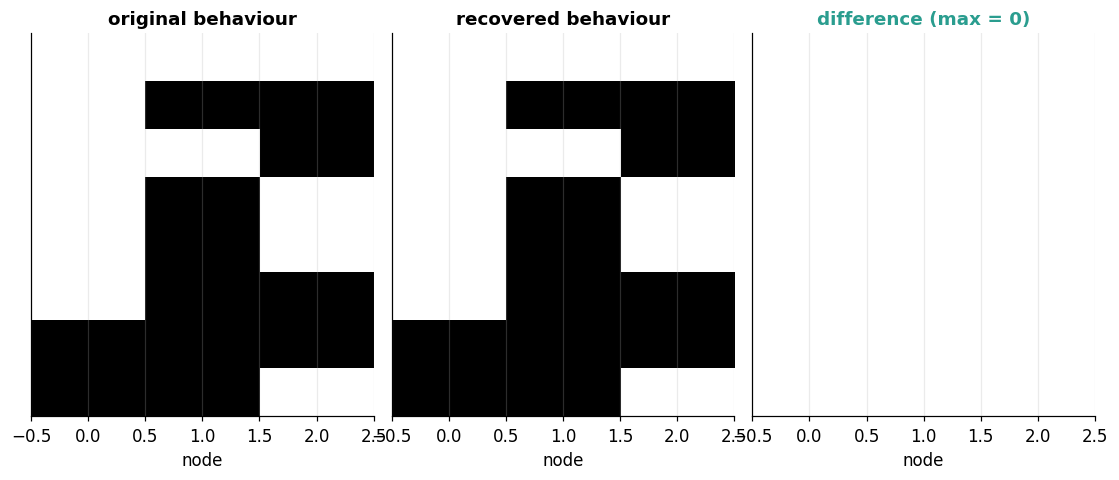

The difference is all zero: the recovered network is behaviourally identical to the original.


In [8]:
# The picture of equivalence: original vs recovered repertoire, and their difference
rep2 = np.array(repertoire(net2))
diff = np.abs(rep - rep2)

fig, axes = plt.subplots(1, 3, figsize=(10, 4.5))
for ax, M, title in zip(axes, [rep, rep2, diff],
                        ["original behaviour", "recovered behaviour", "difference"]):
    ax.imshow(M, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    ax.set_title(title); ax.set_xlabel("node"); ax.set_yticks([])
axes[2].set_title(f"difference (max = {diff.max()})", color=OK)
plt.tight_layout(); plt.show()
print("The difference is all zero: the recovered network is behaviourally identical to the original.")

## 4. It is exact at scale, and it does **not** fit noise

Two facts make this trustworthy. First, the recovery is exact for *any* such
network, not just our toy — we test many random ones. Second, the method does not
"explain" randomness: a random column needs a long, incompressible description,
whereas a structured one collapses to a short rule. Order is recovered only where
it exists.

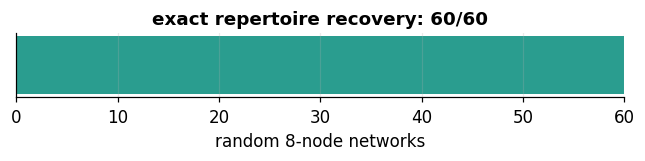

60/60 random networks recovered exactly from their behaviour alone.


In [9]:
from network_generator import random_network

n, trials = 8, 60
exact = 0
for seed in range(trials):
    g = random_network(n, seed=seed)
    rg = repertoire(g)
    gr, reps = deconvolve(rg)
    exact += (repertoire(gr) == rg)

fig, ax = plt.subplots(figsize=(6, 1.6))
ax.barh([0], [exact], color=OK); ax.barh([0], [trials-exact], left=[exact], color=BAD)
ax.set_xlim(0, trials); ax.set_yticks([]); ax.set_xlabel("random 8-node networks")
ax.set_title(f"exact repertoire recovery: {exact}/{trials}")
plt.tight_layout(); plt.show()
print(f"{exact}/{trials} random networks recovered exactly from their behaviour alone.")

## Takeaways

* A Boolean network's **behaviour** (its repertoire) is a table we can read.
* From that table alone we recover the **wiring** (by a causal flip-a-bit test) and
  the **gate** at each node — exactly, and verifiably.
* The method recovers order where it exists and refuses to compress randomness.

**Next (01):** we let the network be a *cellular automaton* — a whole space-time
picture — and recover its rule from the pattern it paints.